# Backtest Results — Data Explorer

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_parquet('../data/backtest.parquet')
btc = df[df.symbol == 'BTC'].copy()
eth = df[df.symbol == 'ETH'].copy()

# Portfolio-level aggregation per timestamp
agg = df.groupby('timestamp').agg(
    funding_pnl=('funding_pnl', 'sum'),
    cost_drag=('cost_drag', 'sum'),
    basis_pnl=('basis_pnl', 'sum'),
    total_pnl=('total_pnl', 'sum'),
    turnover=('turnover', 'sum'),
).sort_index()
agg['cum_pnl'] = agg['total_pnl'].cumsum()
agg['cum_funding'] = agg['funding_pnl'].cumsum()
agg['cum_cost'] = agg['cost_drag'].cumsum()
agg['cum_basis'] = agg['basis_pnl'].cumsum()

PERIODS_PER_YEAR = 365.25 * 3

## Schema

In [2]:
print(f"Rows: {len(df)}, Columns: {list(df.columns)}")
df.dtypes

Rows: 13602, Columns: ['timestamp', 'symbol', 'weight', 'funding_rate', 'turnover', 'funding_pnl', 'cost_drag', 'basis_pnl', 'total_pnl']


timestamp       datetime64[ns, UTC]
symbol                       object
weight                      float64
funding_rate                float64
turnover                    float64
funding_pnl                 float64
cost_drag                   float64
basis_pnl                   float64
total_pnl                   float64
dtype: object

## First & last rows

In [3]:
df.head(10)

,timestamp,symbol,weight,funding_rate,turnover,funding_pnl,cost_drag,basis_pnl,total_pnl
0,2020-01-16 00:00:00+00:00,BTC,0.000000,0.000100,0.000000,0.000000,-0.000000e+00,0.000000,0.000000
1,2020-01-16 08:00:00+00:00,BTC,0.543571,0.000412,0.543571,0.000224,-5.435706e-04,-0.000000,-0.000320
2,2020-01-16 16:00:00+00:00,BTC,0.544274,0.000315,0.000703,0.000171,-7.034199e-07,0.000179,0.000349
3,2020-01-17 00:00:00+00:00,BTC,0.000000,0.000100,0.544274,0.000000,-5.442740e-04,0.000062,-0.000482
4,2020-01-17 08:00:00+00:00,BTC,1.000000,0.000150,1.000000,0.000150,-1.000000e-03,-0.000000,-0.000850
5,2020-01-17 16:00:00+00:00,BTC,0.551118,0.000567,0.448882,0.000313,-4.488818e-04,0.000236,0.000100
6,2020-01-18 00:00:00.001000+00:00,BTC,0.000000,0.000100,0.551118,0.000000,-5.511182e-04,0.000000,-0.000551
7,2020-01-18 08:00:00.001000+00:00,BTC,1.000000,0.000292,1.000000,0.000292,-1.000000e-03,0.000000,-0.000708
8,2020-01-18 16:00:00+00:00,BTC,0.562497,0.000321,0.437503,0.000180,-4.375031e-04,0.000000,-0.000257
9,2020-01-19 00:00:00+00:00,BTC,0.564452,0.000200,0.001955,0.000113,-1.955104e-06,-0.000245,-0.000134


In [4]:
df.tail(10)

,timestamp,symbol,weight,funding_rate,turnover,funding_pnl,cost_drag,basis_pnl,total_pnl
13592,2026-03-28 16:00:00+00:00,ETH,0.0,4.500000e-07,0.0,0.0,-0.0,0.0,0.0
13593,2026-03-29 00:00:00.003000+00:00,ETH,0.0,-1.122000e-05,0.0,-0.0,-0.0,0.0,0.0
13594,2026-03-29 08:00:00.001000+00:00,ETH,0.0,-3.677000e-05,0.0,-0.0,-0.0,0.0,0.0
13595,2026-03-29 16:00:00+00:00,ETH,0.0,-3.760000e-05,0.0,-0.0,-0.0,0.0,0.0
13596,2026-03-30 00:00:00+00:00,ETH,0.0,-2.586000e-05,0.0,-0.0,-0.0,0.0,0.0
13597,2026-03-30 08:00:00.005000+00:00,ETH,0.0,1.177000e-05,0.0,0.0,-0.0,0.0,0.0
13598,2026-03-30 16:00:00+00:00,ETH,0.0,4.113000e-05,0.0,0.0,-0.0,0.0,0.0
13599,2026-03-31 00:00:00+00:00,ETH,0.0,2.570000e-06,0.0,0.0,-0.0,0.0,0.0
13600,2026-03-31 08:00:00+00:00,ETH,0.0,1.748000e-05,0.0,0.0,-0.0,0.0,0.0
13601,2026-03-31 16:00:00+00:00,ETH,0.0,-9.620000e-06,0.0,-0.0,-0.0,0.0,0.0


## Coverage & nulls

In [5]:
for name, sub in [('BTC', btc), ('ETH', eth)]:
    print(f"{name}: {len(sub)} periods, {sub['timestamp'].min()} -> {sub['timestamp'].max()}")
    for col in ['funding_pnl', 'cost_drag', 'basis_pnl', 'total_pnl']:
        nulls = sub[col].isna().sum()
        if nulls > 0:
            print(f"  Null {col}: {nulls}")
    active = (sub['weight'] > 0).sum()
    print(f"  Active: {active}/{len(sub)} ({active/len(sub)*100:.1f}%)")
print(f"\nTotal rows: {len(df)}")
print(f"Portfolio timestamps: {len(agg)}")

BTC: 6801 periods, 2020-01-16 00:00:00+00:00 -> 2026-03-31 16:00:00+00:00
  Active: 1041/6801 (15.3%)
ETH: 6801 periods, 2020-01-16 00:00:00+00:00 -> 2026-03-31 16:00:00+00:00
  Active: 1223/6801 (18.0%)

Total rows: 13602
Portfolio timestamps: 6801


## P&L decomposition summary

Total P&L = funding income + cost drag + basis MtM. Basis captures the spot-perp return differential on the delta-neutral position (should be small).

In [6]:
fund = agg['funding_pnl'].sum() * 10_000
cost = agg['cost_drag'].sum() * 10_000
basis = agg['basis_pnl'].sum() * 10_000
total = agg['total_pnl'].sum() * 10_000
years = len(agg) / PERIODS_PER_YEAR

print(f"{'Component':<20s} {'Total (bps)':>12s} {'Annual (bps)':>12s} {'Share':>8s}")
print('-' * 56)
for label, val in [('Funding income', fund), ('Cost drag', cost), ('Basis (MtM)', basis)]:
    print(f"{label:<20s} {val:>12.1f} {val/years:>12.1f} {val/total*100 if total else 0:>7.1f}%")
print('-' * 56)
print(f"{'Total'::<20s} {total:>12.1f} {total/years:>12.1f}")

Component             Total (bps) Annual (bps)    Share
--------------------------------------------------------
Funding income             6111.6        984.7  2139.6%
Cost drag                 -5954.6       -959.4 -2084.6%
Basis (MtM)                 128.6         20.7    45.0%
--------------------------------------------------------
Total:::::::::::::::        285.6         46.0


## Cumulative P&L curve with decomposition

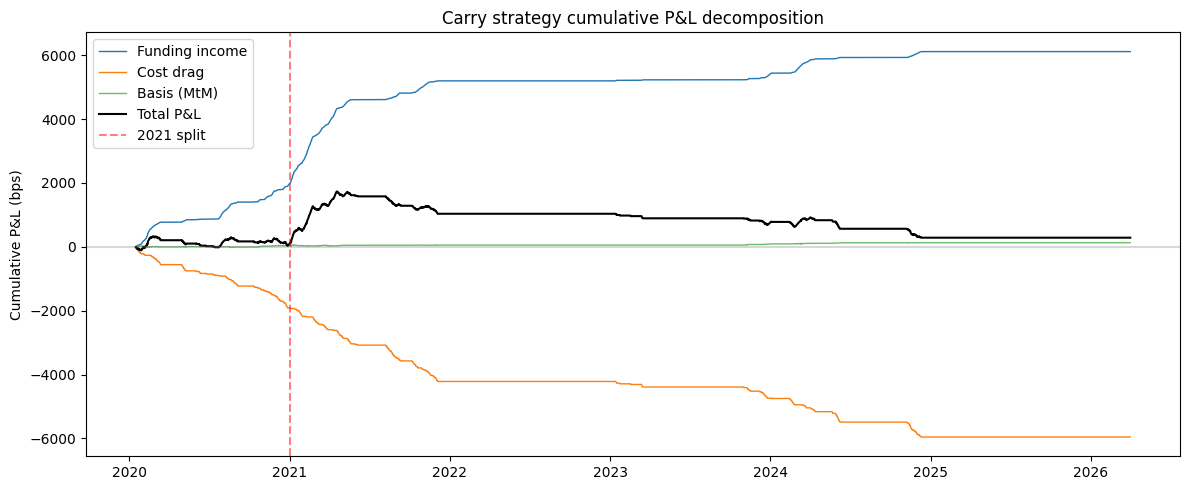

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(agg.index, agg['cum_funding'] * 10_000, label='Funding income', linewidth=1)
ax.plot(agg.index, agg['cum_cost'] * 10_000, label='Cost drag', linewidth=1)
ax.plot(agg.index, agg['cum_basis'] * 10_000, label='Basis (MtM)', linewidth=1, alpha=0.7)
ax.plot(agg.index, agg['cum_pnl'] * 10_000, label='Total P&L', linewidth=1.5, color='black')
ax.axvline(pd.Timestamp('2021-01-01', tz='UTC'), color='red', ls='--', alpha=0.5, label='2021 split')
ax.axhline(0, color='grey', ls='-', alpha=0.3)
ax.set_ylabel('Cumulative P&L (bps)')
ax.set_title('Carry strategy cumulative P&L decomposition')
ax.legend()
plt.tight_layout()
plt.show()

## Per-period P&L distribution

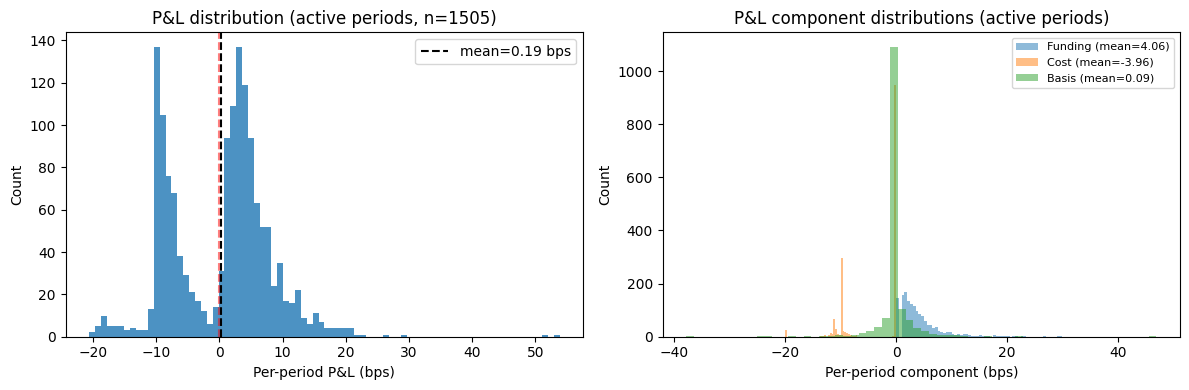

Active periods: 1505/6801 (22.1%)
Win rate: 61.2%
Mean P&L when active: 0.190 bps
Mean P&L (all periods): 0.042 bps


In [8]:
active_pnl = agg.loc[agg['total_pnl'] != 0, 'total_pnl'] * 10_000

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(active_pnl, bins=80, edgecolor='none', alpha=0.8)
ax.axvline(0, color='red', ls='--', alpha=0.5)
ax.axvline(active_pnl.mean(), color='black', ls='--', label=f'mean={active_pnl.mean():.2f} bps')
ax.set_xlabel('Per-period P&L (bps)')
ax.set_ylabel('Count')
ax.set_title(f'P&L distribution (active periods, n={len(active_pnl)})')
ax.legend()

ax = axes[1]
for label, col in [('Funding', 'funding_pnl'), ('Cost', 'cost_drag'), ('Basis', 'basis_pnl')]:
    vals = agg.loc[agg['total_pnl'] != 0, col] * 10_000
    ax.hist(vals, bins=60, alpha=0.5, label=f'{label} (mean={vals.mean():.2f})')
ax.set_xlabel('Per-period component (bps)')
ax.set_ylabel('Count')
ax.set_title('P&L component distributions (active periods)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Active periods: {len(active_pnl)}/{len(agg)} ({len(active_pnl)/len(agg)*100:.1f}%)")
print(f"Win rate: {(active_pnl > 0).mean():.1%}")
print(f"Mean P&L when active: {active_pnl.mean():.3f} bps")
print(f"Mean P&L (all periods): {(agg['total_pnl'] * 10_000).mean():.3f} bps")

## Drawdown analysis

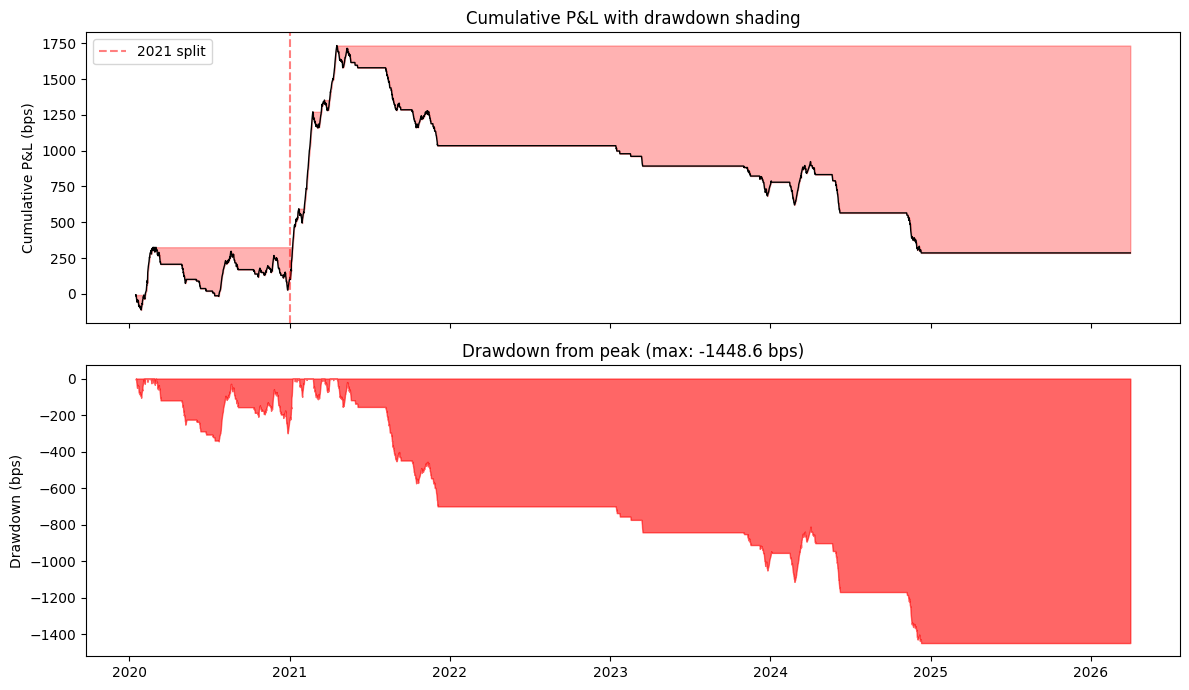

Max drawdown: -1448.6 bps
Max drawdown duration: 5425 periods (1808 days)

Top 5 drawdown troughs:
  2024-12-07: -1436.6 bps
  2024-12-02: -1429.5 bps
  2024-11-30: -1416.3 bps
  2024-11-28: -1378.7 bps
  2024-11-25: -1366.5 bps


In [9]:
cum = agg['cum_pnl'].values * 10_000
peak = np.maximum.accumulate(cum)
dd = cum - peak

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.plot(agg.index, cum, linewidth=1, color='black')
ax.fill_between(agg.index, cum, peak, alpha=0.3, color='red')
ax.axvline(pd.Timestamp('2021-01-01', tz='UTC'), color='red', ls='--', alpha=0.5, label='2021 split')
ax.set_ylabel('Cumulative P&L (bps)')
ax.set_title('Cumulative P&L with drawdown shading')
ax.legend()

ax = axes[1]
ax.fill_between(agg.index, dd, 0, alpha=0.6, color='red')
ax.set_ylabel('Drawdown (bps)')
ax.set_title(f'Drawdown from peak (max: {dd.min():.1f} bps)')

plt.tight_layout()
plt.show()

# Drawdown stats
print(f"Max drawdown: {dd.min():.1f} bps")

# Find max DD duration
underwater = dd < -0.001
best = current = 0
for v in underwater:
    if v:
        current += 1
        best = max(best, current)
    else:
        current = 0
print(f"Max drawdown duration: {best} periods ({best/3:.0f} days)")

# Top 5 drawdowns by depth
from scipy.signal import argrelextrema
troughs = np.where((dd[1:-1] < dd[:-2]) & (dd[1:-1] < dd[2:]))[0] + 1
worst = sorted(troughs, key=lambda i: dd[i])[:5]
print(f"\nTop 5 drawdown troughs:")
for i in worst:
    print(f"  {agg.index[i].strftime('%Y-%m-%d')}: {dd[i]:.1f} bps")

## Rolling Sharpe (90-day window, annualized)

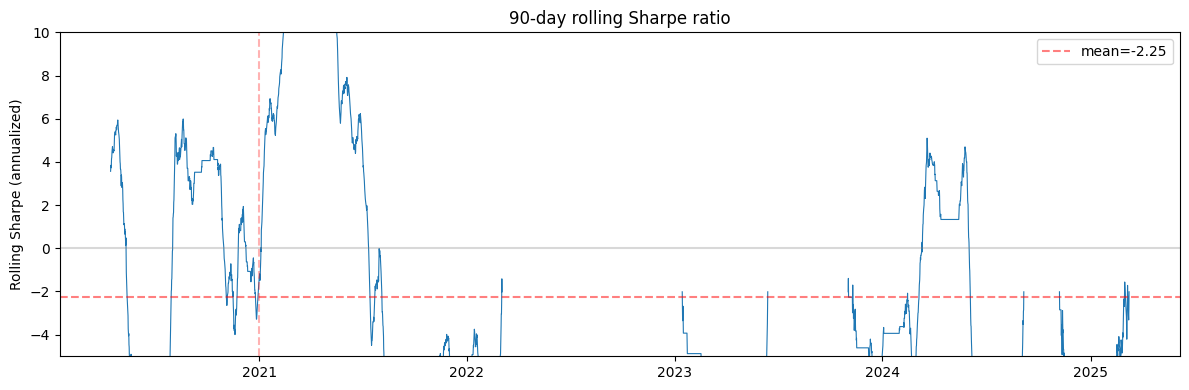

Full-period Sharpe: 0.370
% of time Sharpe > 0: 31.7%
% of time Sharpe > 1: 30.3%


In [10]:
window = 90 * 3  # 90 days in 8h periods
roll_mean = agg['total_pnl'].rolling(window).mean()
roll_std = agg['total_pnl'].rolling(window).std()
roll_sharpe = (roll_mean / roll_std) * np.sqrt(PERIODS_PER_YEAR)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(agg.index, roll_sharpe, linewidth=0.8)
ax.axhline(0, color='grey', ls='-', alpha=0.3)
ax.axhline(roll_sharpe.mean(), color='red', ls='--', alpha=0.5,
           label=f'mean={roll_sharpe.mean():.2f}')
ax.axvline(pd.Timestamp('2021-01-01', tz='UTC'), color='red', ls='--', alpha=0.3)
ax.set_ylabel('Rolling Sharpe (annualized)')
ax.set_title('90-day rolling Sharpe ratio')
ax.set_ylim(-5, 10)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Full-period Sharpe: {agg['total_pnl'].mean() / agg['total_pnl'].std() * np.sqrt(PERIODS_PER_YEAR):.3f}")
print(f"% of time Sharpe > 0: {(roll_sharpe.dropna() > 0).mean():.1%}")
print(f"% of time Sharpe > 1: {(roll_sharpe.dropna() > 1).mean():.1%}")

## Per-asset P&L breakdown

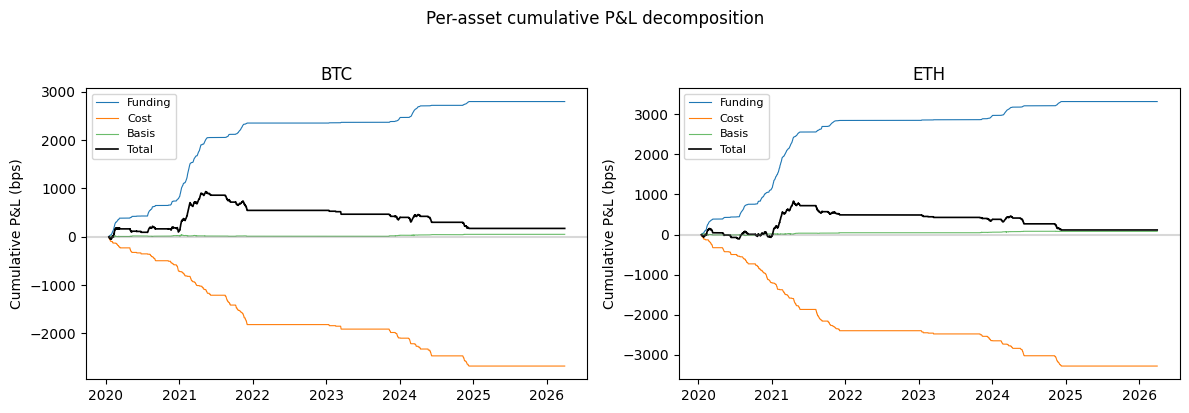

,funding_bps,cost_bps,basis_bps,total_bps
symbol,,,,
BTC,2795.4,-2673.2,50.2,172.4
ETH,3316.3,-3281.3,78.4,113.3


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, sub) in zip(axes, [('BTC', btc), ('ETH', eth)]):
    sub_sorted = sub.sort_values('timestamp')
    cum_f = sub_sorted['funding_pnl'].cumsum() * 10_000
    cum_c = sub_sorted['cost_drag'].cumsum() * 10_000
    cum_b = sub_sorted['basis_pnl'].cumsum() * 10_000
    cum_t = sub_sorted['total_pnl'].cumsum() * 10_000
    ax.plot(sub_sorted['timestamp'], cum_f, label='Funding', linewidth=0.8)
    ax.plot(sub_sorted['timestamp'], cum_c, label='Cost', linewidth=0.8)
    ax.plot(sub_sorted['timestamp'], cum_b, label='Basis', linewidth=0.8, alpha=0.7)
    ax.plot(sub_sorted['timestamp'], cum_t, label='Total', linewidth=1.2, color='black')
    ax.axhline(0, color='grey', ls='-', alpha=0.3)
    ax.set_ylabel('Cumulative P&L (bps)')
    ax.set_title(f'{name}')
    ax.legend(fontsize=8)
plt.suptitle('Per-asset cumulative P&L decomposition', y=1.02)
plt.tight_layout()
plt.show()

rows = []
for name, sub in [('BTC', btc), ('ETH', eth)]:
    rows.append({
        'symbol': name,
        'funding_bps': round(sub['funding_pnl'].sum() * 10_000, 1),
        'cost_bps': round(sub['cost_drag'].sum() * 10_000, 1),
        'basis_bps': round(sub['basis_pnl'].sum() * 10_000, 1),
        'total_bps': round(sub['total_pnl'].sum() * 10_000, 1),
    })
pd.DataFrame(rows).set_index('symbol')

## Pre-2021 vs post-2021 regime comparison

In [12]:
split = pd.Timestamp('2021-01-01', tz='UTC')
rows = []
for label, sub in [('Pre-2021', agg[agg.index < split]), ('Post-2021', agg[agg.index >= split]), ('Full', agg)]:
    pnl = sub['total_pnl'].values
    n = len(pnl)
    yrs = n / PERIODS_PER_YEAR
    cum = np.cumsum(pnl)
    peak = np.maximum.accumulate(cum)
    dd = cum - peak
    sharpe = pnl.mean() / pnl.std() * np.sqrt(PERIODS_PER_YEAR) if pnl.std() > 0 else 0

    rows.append({
        'regime': label,
        'periods': n,
        'years': round(yrs, 1),
        'sharpe': round(sharpe, 3),
        'total_bps': round(cum[-1] * 10_000, 1),
        'annual_bps': round(cum[-1] * 10_000 / yrs, 1),
        'max_dd_bps': round(dd.min() * 10_000, 1),
        'funding_bps': round(sub['funding_pnl'].sum() * 10_000, 1),
        'cost_bps': round(sub['cost_drag'].sum() * 10_000, 1),
        'basis_bps': round(sub['basis_pnl'].sum() * 10_000, 1),
    })
pd.DataFrame(rows).set_index('regime')

,periods,years,sharpe,total_bps,annual_bps,max_dd_bps,funding_bps,cost_bps,basis_bps
regime,,,,,,,,,
Pre-2021,1053,1.0,0.611,104.0,108.2,-343.7,1979.4,-1910.4,35.0
Post-2021,5748,5.2,0.309,181.6,34.6,-1448.6,4132.2,-4044.2,93.6
Full,6801,6.2,0.370,285.6,46.0,-1448.6,6111.6,-5954.6,128.6


## Yearly P&L summary

In [13]:
df['year'] = df['timestamp'].dt.year
yearly = df.groupby(['year', 'symbol']).agg(
    funding_bps=('funding_pnl', lambda x: x.sum() * 10_000),
    cost_bps=('cost_drag', lambda x: x.sum() * 10_000),
    basis_bps=('basis_pnl', lambda x: x.sum() * 10_000),
    total_bps=('total_pnl', lambda x: x.sum() * 10_000),
    pct_active=('weight', lambda x: (x > 0).mean() * 100),
).round(1)
yearly

funding_bps  cost_bps  basis_bps  total_bps  pct_active
year symbol                                                         
2020 BTC           825.7    -710.2       21.2      136.7        27.4
     ETH          1153.8   -1200.2       13.7      -32.7        38.7
2021 BTC          1525.4   -1105.7      -11.2      408.5        42.9
     ETH          1691.1   -1199.7       30.6      522.0        45.4
2022 BTC             0.0       0.0        0.0        0.0         0.0
     ETH             0.0       0.0        0.0        0.0         0.0
2023 BTC            99.2    -275.4       18.9     -157.2         6.3
     ETH           111.3    -247.0       13.8     -122.0         6.9
2024 BTC           345.1    -582.0       21.2     -215.7        19.4
     ETH           360.2    -634.5       20.2     -254.1        22.0
2025 BTC             0.0       0.0        0.0        0.0         0.0
     ETH             0.0       0.0        0.0        0.0         0.0
2026 BTC             0.0       0.0        0.0        0.0         0.0
     ETH             0.0       0.0        0.0        0.0         0.0

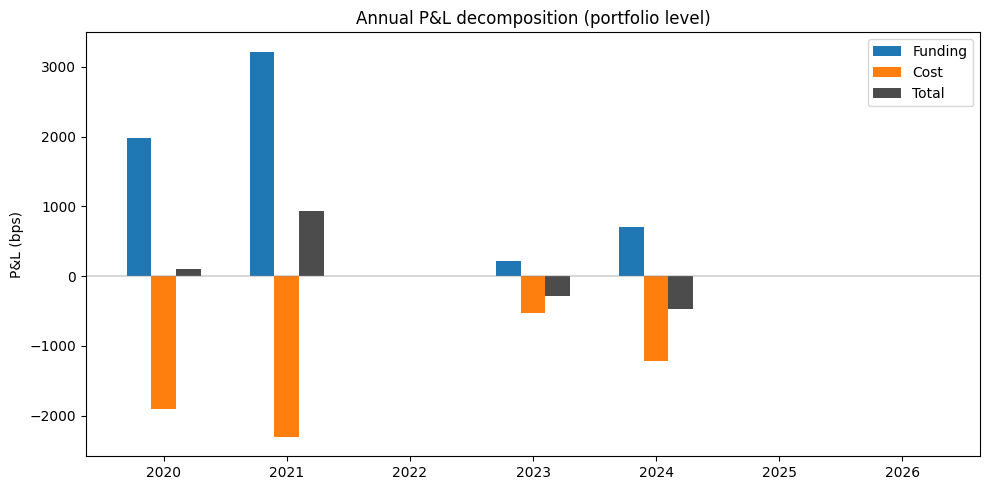

,funding_bps,cost_bps,basis_bps,total_bps
year,,,,
2020,1979.4,-1910.4,35.0,104.0
2021,3216.4,-2305.3,19.5,930.6
2022,0.0,0.0,0.0,0.0
2023,210.5,-522.4,32.7,-279.2
2024,705.3,-1216.4,41.4,-469.8
2025,0.0,0.0,0.0,0.0
2026,0.0,0.0,0.0,0.0


In [14]:
# Portfolio-level yearly summary
agg_yearly = agg.copy()
agg_yearly['year'] = agg_yearly.index.year
ysum = agg_yearly.groupby('year').agg(
    funding_bps=('funding_pnl', lambda x: x.sum() * 10_000),
    cost_bps=('cost_drag', lambda x: x.sum() * 10_000),
    basis_bps=('basis_pnl', lambda x: x.sum() * 10_000),
    total_bps=('total_pnl', lambda x: x.sum() * 10_000),
).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ysum))
w = 0.2
ax.bar(x - w, ysum['funding_bps'], w, label='Funding')
ax.bar(x, ysum['cost_bps'], w, label='Cost')
ax.bar(x + w, ysum['total_bps'], w, label='Total', color='black', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(ysum.index)
ax.set_ylabel('P&L (bps)')
ax.set_title('Annual P&L decomposition (portfolio level)')
ax.axhline(0, color='grey', ls='-', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

ysum

## Threshold sweep

How Sharpe and P&L change across funding rate entry thresholds (spread fixed at 5 bps/side).

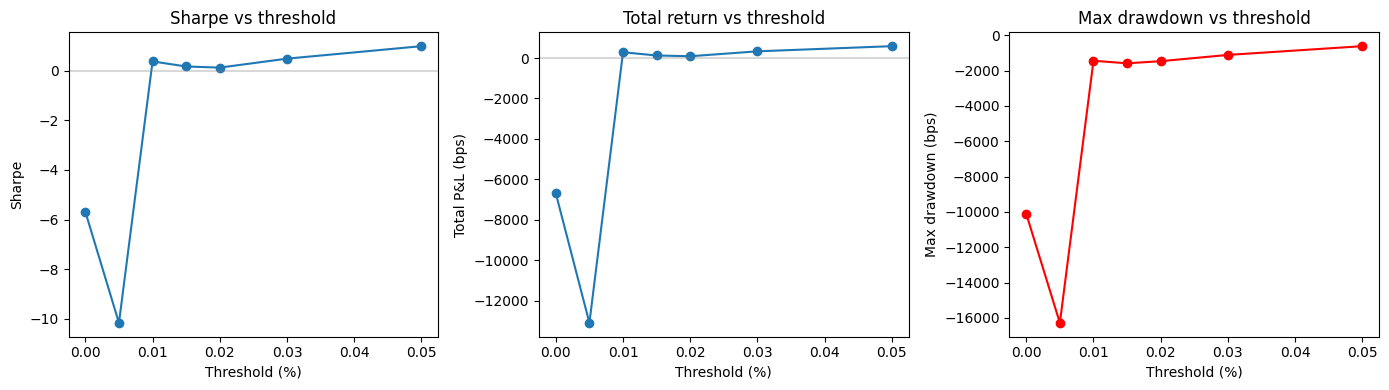

,threshold,sharpe,total_bps,annual_bps,max_dd_bps,win_rate
0,0.0,-5.684,-6686.554,-1077.311,-10108.972,0.694
1,0.0,-10.160,-13095.471,-2109.890,-16281.177,0.586
2,0.0,0.370,285.638,46.021,-1448.578,0.612
3,0.0,0.165,126.085,20.314,-1592.968,0.582
4,0.0,0.120,88.257,14.220,-1472.483,0.543
5,0.0,0.481,331.553,53.418,-1117.895,0.503
6,0.0,0.983,586.515,94.497,-623.092,0.457


In [15]:
tsweep = pd.read_csv('../output/threshold_sweep.csv')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.plot(tsweep['threshold'] * 100, tsweep['sharpe'], 'o-')
ax.axhline(0, color='grey', ls='-', alpha=0.3)
ax.set_xlabel('Threshold (%)')
ax.set_ylabel('Sharpe')
ax.set_title('Sharpe vs threshold')

ax = axes[1]
ax.plot(tsweep['threshold'] * 100, tsweep['total_bps'], 'o-')
ax.axhline(0, color='grey', ls='-', alpha=0.3)
ax.set_xlabel('Threshold (%)')
ax.set_ylabel('Total P&L (bps)')
ax.set_title('Total return vs threshold')

ax = axes[2]
ax.plot(tsweep['threshold'] * 100, tsweep['max_dd_bps'], 'o-', color='red')
ax.set_xlabel('Threshold (%)')
ax.set_ylabel('Max drawdown (bps)')
ax.set_title('Max drawdown vs threshold')

plt.tight_layout()
plt.show()

tsweep[['threshold', 'sharpe', 'total_bps', 'annual_bps', 'max_dd_bps', 'win_rate']].round(3)

## Spread sweep

How Sharpe and P&L change across transaction cost assumptions (threshold fixed at 0.01%).

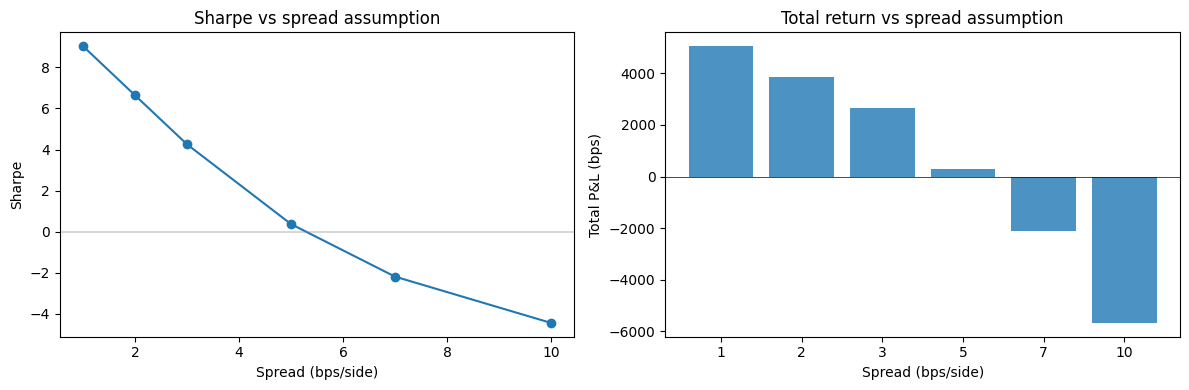

Breakeven spread: ~5.2 bps/side


,spread_bps,sharpe,total_bps,annual_bps,funding_bps,cost_bps
0,1,9.0,5049.3,813.5,6111.6,-1190.9
1,2,6.6,3858.4,621.6,6111.6,-2381.8
2,3,4.3,2667.5,429.8,6111.6,-3572.7
3,5,0.4,285.6,46.0,6111.6,-5954.6
4,7,-2.2,-2096.2,-337.7,6111.6,-8336.4
5,10,-4.4,-5668.9,-913.4,6111.6,-11909.1


In [16]:
ssweep = pd.read_csv('../output/spread_sweep.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(ssweep['spread_bps'], ssweep['sharpe'], 'o-')
ax.axhline(0, color='grey', ls='-', alpha=0.3)
ax.set_xlabel('Spread (bps/side)')
ax.set_ylabel('Sharpe')
ax.set_title('Sharpe vs spread assumption')

ax = axes[1]
ax.bar(ssweep['spread_bps'].astype(str), ssweep['total_bps'], alpha=0.8)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Spread (bps/side)')
ax.set_ylabel('Total P&L (bps)')
ax.set_title('Total return vs spread assumption')

plt.tight_layout()
plt.show()

# Breakeven spread
from scipy.interpolate import interp1d
f = interp1d(ssweep['total_bps'], ssweep['spread_bps'], kind='linear')
try:
    be = f(0)
    print(f"Breakeven spread: ~{float(be):.1f} bps/side")
except:
    print("Breakeven spread outside interpolation range")

ssweep[['spread_bps', 'sharpe', 'total_bps', 'annual_bps', 'funding_bps', 'cost_bps']].round(1)

## Basis P&L deep-dive

The basis (MtM) component captures the spot-perp return differential while holding the carry position. Should be small and mean-reverting for a delta-neutral trade.

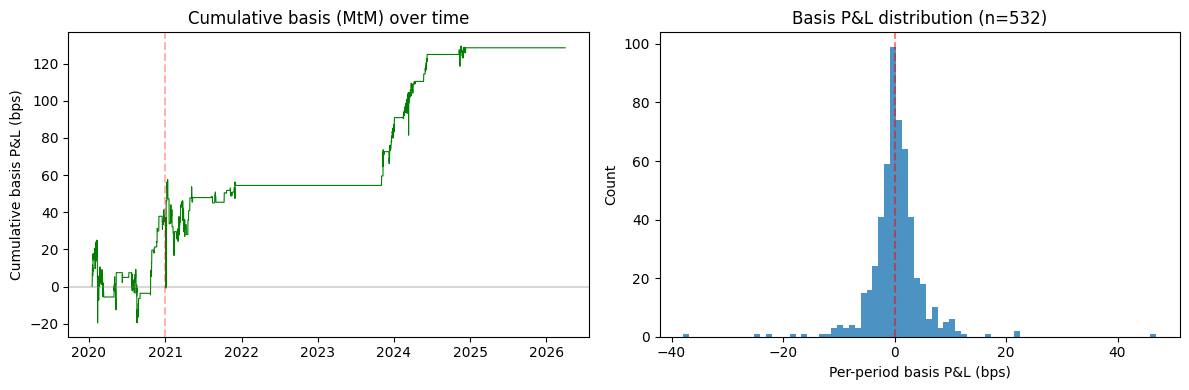

Total basis P&L: 128.6 bps
Mean per active period: 0.242 bps
Std per active period: 5.043 bps
Basis as % of funding: 2.1%


In [17]:
basis_active = agg.loc[agg['basis_pnl'] != 0, 'basis_pnl'] * 10_000

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(agg.index, agg['cum_basis'] * 10_000, linewidth=0.8, color='green')
ax.axhline(0, color='grey', ls='-', alpha=0.3)
ax.axvline(pd.Timestamp('2021-01-01', tz='UTC'), color='red', ls='--', alpha=0.3)
ax.set_ylabel('Cumulative basis P&L (bps)')
ax.set_title('Cumulative basis (MtM) over time')

ax = axes[1]
ax.hist(basis_active, bins=80, edgecolor='none', alpha=0.8)
ax.axvline(0, color='red', ls='--', alpha=0.5)
ax.set_xlabel('Per-period basis P&L (bps)')
ax.set_ylabel('Count')
ax.set_title(f'Basis P&L distribution (n={len(basis_active)})')

plt.tight_layout()
plt.show()

print(f"Total basis P&L: {agg['basis_pnl'].sum() * 10_000:.1f} bps")
print(f"Mean per active period: {basis_active.mean():.3f} bps")
print(f"Std per active period: {basis_active.std():.3f} bps")
print(f"Basis as % of funding: {agg['basis_pnl'].sum() / agg['funding_pnl'].sum() * 100:.1f}%")

## Performance metrics summary table

In [18]:
def metrics_row(label, pnl_series, turnover_series):
    pnl = pnl_series.values
    n = len(pnl)
    yrs = n / PERIODS_PER_YEAR
    cum = np.cumsum(pnl)
    peak = np.maximum.accumulate(cum)
    dd = cum - peak
    sharpe = pnl.mean() / pnl.std() * np.sqrt(PERIODS_PER_YEAR) if pnl.std() > 0 else 0
    active = pnl[pnl != 0]
    return {
        'regime': label,
        'sharpe': round(sharpe, 3),
        'total_bps': round(cum[-1] * 10_000, 1),
        'annual_bps': round(cum[-1] * 10_000 / yrs, 1),
        'max_dd_bps': round(dd.min() * 10_000, 1),
        'mean_turnover': round(turnover_series.mean(), 4),
        'win_rate': f"{(active > 0).mean():.1%}" if len(active) > 0 else "N/A",
    }

split = pd.Timestamp('2021-01-01', tz='UTC')
rows = []
for label, sub in [('Full period', agg),
                    ('Pre-2021', agg[agg.index < split]),
                    ('Post-2021', agg[agg.index >= split]),
                    ('2021 only', agg[(agg.index >= '2021') & (agg.index < '2022')]),
                    ('2023-2024', agg[(agg.index >= '2023') & (agg.index < '2025')])]:
    rows.append(metrics_row(label, sub['total_pnl'], sub['turnover']))

pd.DataFrame(rows).set_index('regime')

,sharpe,total_bps,annual_bps,max_dd_bps,mean_turnover,win_rate
regime,,,,,,
Full period,0.370,285.6,46.0,-1448.6,0.0876,61.2%
Pre-2021,0.611,104.0,108.2,-343.7,0.1814,61.1%
Post-2021,0.309,181.6,34.6,-1448.6,0.0704,61.2%
2021 only,4.334,930.6,931.2,-699.6,0.2105,64.5%
2023-2024,-3.888,-749.0,-374.2,-749.0,0.0793,55.9%


## Monthly P&L heatmap

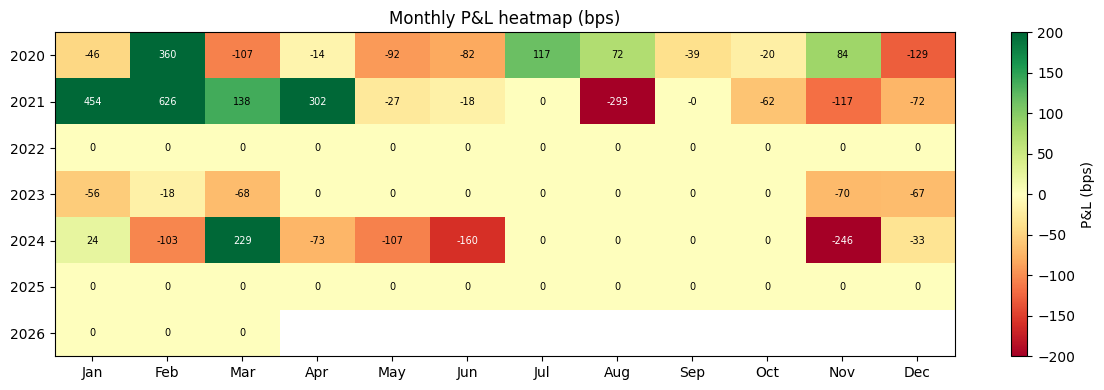

In [19]:
monthly = agg.copy()
monthly['year'] = monthly.index.year
monthly['month'] = monthly.index.month
mpnl = monthly.groupby(['year', 'month'])['total_pnl'].sum() * 10_000
pivot = mpnl.unstack(level='month')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][:len(pivot.columns)]

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=-200, vmax=200)
ax.set_xticks(range(pivot.shape[1]))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(pivot.shape[0]))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7,
                    color='black' if abs(v) < 150 else 'white')
plt.colorbar(im, label='P&L (bps)')
ax.set_title('Monthly P&L heatmap (bps)')
plt.tight_layout()
plt.show()

## Threshold × spread sensitivity grid

Joint sensitivity: how does optimal threshold shift under different cost assumptions?

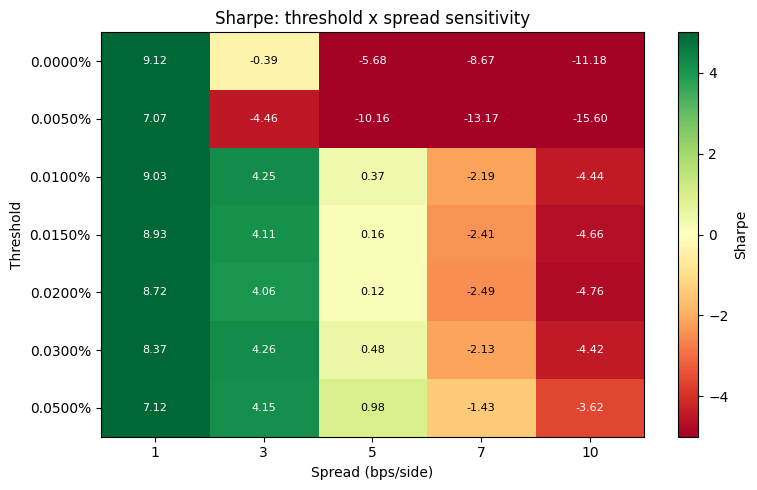

In [20]:
import importlib.util, os, sys

_spec = importlib.util.spec_from_file_location(
    "bt", os.path.join(os.path.abspath('../src'), "4_backtest.py"))
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)

signals = _mod.load_signals()
prices = _mod.load_8h_prices()

thresholds = [0.0, 0.00005, 0.0001, 0.00015, 0.0002, 0.0003, 0.0005]
spreads = [1, 3, 5, 7, 10]
grid = np.zeros((len(thresholds), len(spreads)))

for i, t in enumerate(thresholds):
    for j, s in enumerate(spreads):
        bt = _mod.run_backtest(signals, prices, threshold=t, spread_bps=s)
        a = _mod.aggregate_pnl(bt)
        pnl = a['total_pnl'].values
        grid[i, j] = pnl.mean() / pnl.std() * np.sqrt(PERIODS_PER_YEAR) if pnl.std() > 0 else 0

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(grid, aspect='auto', cmap='RdYlGn', vmin=-5, vmax=5)
ax.set_xticks(range(len(spreads)))
ax.set_xticklabels([f'{s}' for s in spreads])
ax.set_yticks(range(len(thresholds)))
ax.set_yticklabels([f'{t*100:.4f}%' for t in thresholds])
ax.set_xlabel('Spread (bps/side)')
ax.set_ylabel('Threshold')
for i in range(len(thresholds)):
    for j in range(len(spreads)):
        ax.text(j, i, f'{grid[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='black' if abs(grid[i,j]) < 3 else 'white')
plt.colorbar(im, label='Sharpe')
ax.set_title('Sharpe: threshold x spread sensitivity')
plt.tight_layout()
plt.show()